# Conditional Flow Matching

In this lab session, you will implement a simple conditional flow matching model for a toy 2D problem.

## Dataset formatting

Before delving into the implementation, you will need to prepare data to feed to the neural network during training. We will rely on a well-known toy dataset: the 2 Moons dataset.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"

In [2]:
from sklearn.datasets import make_moons
import numpy as np

n_samples = 20000
noise = 0.05
moons, _ = make_moons(n_samples=n_samples, noise=noise)
moons = moons.astype(np.float32)
perm = np.random.permutation(len(moons))
split = int(0.9 * len(moons))

# Training set
train_x = moons[perm[:split]]
# Validation set
val_x = moons[perm[split:]]

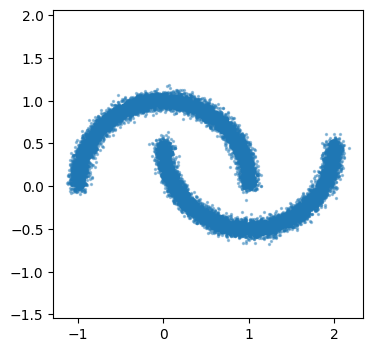

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.scatter(train_x[:,0], train_x[:,1], s=2, alpha=0.4)
plt.axis('equal')
plt.show()

Now, recall that in conditional flow matching, we need to train a neural network to predict the velocity field by minimizing the following loss function:

\begin{equation}
\mathcal{L}(\theta) = \mathbb{E}_{t \sim \mathcal{U}(0, 1), \mathbf{x}_0 \sim p_0, \mathbf{x}_1 \sim p_{\text{data}}} \left[ \| \mathbf{v}_\theta(\mathbf{x}, t) - \mathbf{v}_t \|^2_2 \right]
\end{equation}

where 
\begin{equation}
\mathbf{x} = (1 - t) \mathbf{x}_0 + t \mathbf{x}_1
\end{equation}
 
and 
\begin{equation}
\mathbf{v}_t = \mathbf{x}_1 - \mathbf{x}_0
\end{equation}

is the target velocity field.

We will hence train our neural network $\mathbf{v}_\theta$ on samples of the form $(\mathbf{x}, t)$ as inputs and $\mathbf{v}_t$ as targets.

**Question 1.** Implement a custom data generator that will yield batches of samples during training.
In `keras`, this can be achieved by defining a class that inherits from the `Sequence` class:

In [4]:
from keras.utils import Sequence

class MoonsSequence(Sequence):
    def __init__(self, x, batch_size=256):
        self.x = x
        self.batch_size = batch_size
        self.n = len(x)

    def __len__(self):
        return int(np.ceil(self.n / self.batch_size))

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = min(start + self.batch_size, self.n)
        x1 = self.x[start:end]
        B = len(x1)
        x0 = np.random.randn(B, 2).astype(np.float32)
        t = np.random.rand(B, 1).astype(np.float32)
        xt = (1 - t) * x0 + t * x1
        target_v = x1 - x0
        return {'x': xt, 't': t}, target_v

batch_size = 256
train_seq = MoonsSequence(train_x, batch_size=batch_size)
val_seq = MoonsSequence(val_x, batch_size=batch_size)

## Velocity field model

For our velocity field model $\mathbf{v}_\theta$, we will use a simple feedforward neural network with fully connected layers.
This network will take as input the concatenation of the 2D point $\mathbf{x}$ and the time $t$, and will output a 2D vector representing the velocity at that point and time.

**Question 2.** Implement the velocity field model by filling the code below. As you can see, we cannot use the `Sequential` model of `keras` here, since we need to process two different types of inputs (the 2D point and the time). Instead, we will inherit from the `Model` class from `keras`. The `__init__` method is given to you and you will need to implement the `call` method that defines the forward pass of the model (i.e. computes the output of the model from `x` and `t` given as inputs).

In [5]:
from keras.models import Model, Sequential
from keras.layers import Dense, Concatenate

class VelocityField(Model):
    def __init__(self, hidden_size=256):
        super().__init__()
        self.net = Sequential([
            Dense(units=hidden_size, activation="relu"),
            Dense(units=2)
        ])
        self.concatenate = Concatenate()
    
    def call(self, inputs):
        # Accept either a dict {'x': x, 't': t} or a tuple (x, t)
        if isinstance(inputs, dict):
            x = inputs['x']
            t = inputs['t']
        else:
            x, t = inputs
        x_and_t = self.concatenate([x, t])
        v_t_pred = self.net(x_and_t)
        return v_t_pred


**Question 3.** Train your model for 200 epochs using the Adam optimizer with a learning rate of 0.001 and visualize training and validation losses.

Epoch 1/200


/Users/rtavenar/py3.10_ml/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4489 - val_loss: 1.1763
Epoch 2/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1533 - val_loss: 1.0988
Epoch 3/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1085 - val_loss: 1.0751
Epoch 4/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0503 - val_loss: 1.0330
Epoch 5/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0770 - val_loss: 1.0546
Epoch 6/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0476 - val_loss: 1.0627
Epoch 7/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0371 - val_loss: 1.0503
Epoch 8/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0459 - val_loss: 1.0292
Epoch 9/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0574 - val_loss: 1.0237
Epoch 10/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0374 - val_loss: 1.0906
Epoch 11/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0277 - val_loss: 1.0407
Epoch 12/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0428 - val_lo

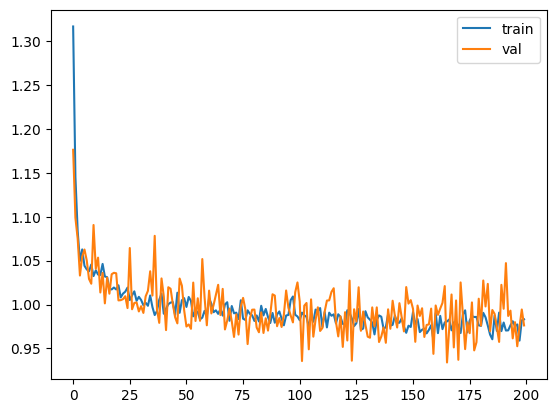

In [6]:
from keras.optimizers import Adam

model = VelocityField()

opt = Adam(learning_rate=1e-3)
model.compile(optimizer=opt, loss='mse')
history = model.fit(train_seq, validation_data=val_seq, epochs=200)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

## Data generation

Now that you have a trained velocity field model, you can use it to generate new samples from the learned distribution.
To do so, we will implement the Euler-Maruyama method to solve the ODE defined by the learned velocity field.
This involves:
1. sampling initial points $\mathbf{x}_0$ from our prior distribution $p_0$,
2. iteratively updating the position of particles based on the predicted velocity field at each time step, up to time $t=1$:
\begin{equation}
\mathbf{x}_{t+\Delta t} = \mathbf{x}_t + \Delta t \cdot \mathbf{v}_\theta(\mathbf{x}_t, t) 
\end{equation}

**Question 4.** Fill in the blanks below to implement the data generation process using a trained velocity field model.

In [7]:
def sample_flow_keras(model, n_samples=1000, n_steps=200):
    x = np.random.randn(n_samples, 2).astype(np.float32)
    ts = np.linspace(0., 1., n_steps + 1, dtype=np.float32)
    dt = ts[1] - ts[0]
    for t in ts[:-1]:
        t_batch = np.full((n_samples, 1), t, dtype=np.float32)
        v = model.predict({'x': x, 't': t_batch}, batch_size=1024, verbose=0)
        x = x + dt * v
    return x


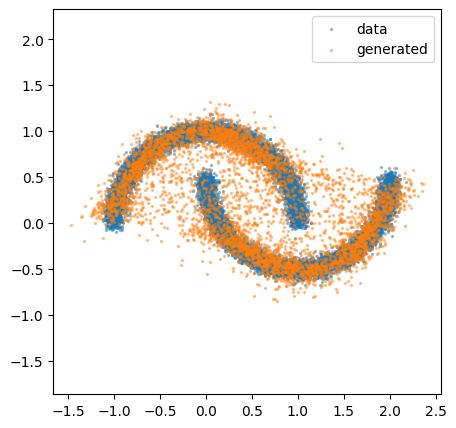

In [8]:
samples = sample_flow_keras(model, n_samples=5000, n_steps=1000)

plt.figure(figsize=(5,5))
plt.scatter(train_x[:,0], train_x[:,1], s=2, alpha=0.4, label='data')
plt.scatter(samples[:,0], samples[:,1], s=2, alpha=0.4, label='generated')
plt.legend()
plt.axis('equal')
plt.show()

## Improvements to the base model

The data generator you get from the previous section is quite basic and can be improved in several ways.

A first way to improve on that model would be tu encode time $t$ in a richer way. Fourier features have been shown to be effective in that regard.

**Question 5.** Using the code below, implement Fourier feature encoding for time $t$ in your velocity field model, retrain your model and generate new samples. Compare the results with the base model.

In [9]:
from keras.layers import Layer
from keras import ops
import math

class FourierTime(Layer):
    def __init__(self, K=16, **kwargs):
        super().__init__(**kwargs)
        self.K = K
        freqs = 2 ** ops.arange(self.K, dtype=np.float32)
        self.freqs = freqs.reshape((1, self.K))

    def call(self, t):
        angles = 2 * math.pi * t * self.freqs
        s = ops.sin(angles)
        c = ops.cos(angles)
        return ops.concatenate((t, s, c), axis=-1)

In [10]:
class VelocityField(Model):
    def __init__(self, hidden_size=256, fourier_features=16):
        super().__init__()
        # Use Fourier encoding for time; input size will be inferred at first call
        self.net = Sequential([
            Dense(units=hidden_size, activation="relu"),
            Dense(units=2)
        ])
        self.concatenate = Concatenate()
        self.fourier = FourierTime(K=fourier_features)
    
    def call(self, inputs):
        # Accept either a dict {'x': x, 't': t} or a tuple (x, t)
        if isinstance(inputs, dict):
            x = inputs['x']
            t = inputs['t']
        else:
            x, t = inputs
        t_emb = self.fourier(t)
        x_and_t = self.concatenate([x, t_emb])
        v_t_pred = self.net(x_and_t)
        return v_t_pred

Epoch 1/200
17/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7136

/Users/rtavenar/py3.10_ml/lib/python3.10/site-packages/keras/src/layers/layer.py:1387: UserWarning: Layer 'velocity_field_1' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: ''Exception encountered when calling FourierTime.call().

Tensor on device mps:0 is not on the expected device meta!

Arguments received by FourierTime.call():
  • t=torch.Tensor(shape=torch.Size([256, 1]), dtype=float32)''
  warnings.warn(
/Users/rtavenar/py3.10_ml/lib/python3.10/site-packa

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5397 - val_loss: 1.2771
Epoch 2/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2555 - val_loss: 1.1952
Epoch 3/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1797 - val_loss: 1.1487
Epoch 4/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1364 - val_loss: 1.1264
Epoch 5/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0871 - val_loss: 1.0986
Epoch 6/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0796 - val_loss: 1.1189
Epoch 7/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0962 - val_loss: 1.0742
Epoch 8/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0895 - val_loss: 1.0941
Epoch 9/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0610 - val_loss: 1.0676
Epoch 10/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0812 - val_loss: 1.0321
Epoch 11/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0519 - val_loss: 1.0972
Epoch 12/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0753 - val_lo

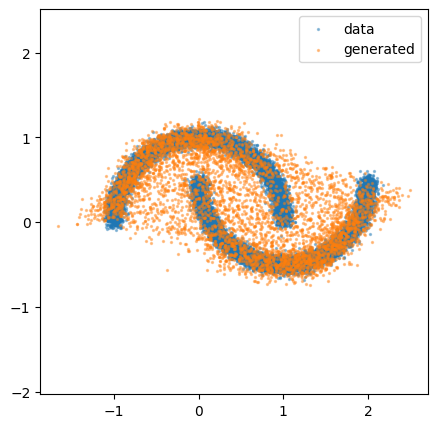

In [11]:
model = VelocityField()

opt = Adam(learning_rate=1e-3)
model.compile(optimizer=opt, loss='mse')
history = model.fit(train_seq, validation_data=val_seq, epochs=200)

samples = sample_flow_keras(model, n_samples=5000, n_steps=1000)

plt.figure(figsize=(5,5))
plt.scatter(train_x[:,0], train_x[:,1], s=2, alpha=0.4, label='data')
plt.scatter(samples[:,0], samples[:,1], s=2, alpha=0.4, label='generated')
plt.legend()
plt.axis('equal')
plt.show()

**Question 6.** You might have seen that the score for the last epoch was not the best one. Set up early stopping such that the best model is recovered after the last iteration.

Epoch 1/200
15/71 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5899

/Users/rtavenar/py3.10_ml/lib/python3.10/site-packages/keras/src/layers/layer.py:1387: UserWarning: Layer 'velocity_field_2' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: ''Exception encountered when calling FourierTime.call().

Tensor on device mps:0 is not on the expected device meta!

Arguments received by FourierTime.call():
  • t=torch.Tensor(shape=torch.Size([256, 1]), dtype=float32)''
  warnings.warn(
/Users/rtavenar/py3.10_ml/lib/python3.10/site-packa

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4664 - val_loss: 1.2712
Epoch 2/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2449 - val_loss: 1.2199
Epoch 3/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1433 - val_loss: 1.1604
Epoch 4/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1112 - val_loss: 1.1212
Epoch 5/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0909 - val_loss: 1.0728
Epoch 6/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0851 - val_loss: 1.0439
Epoch 7/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0782 - val_loss: 1.1074
Epoch 8/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0693 - val_loss: 1.0939
Epoch 9/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0597 - val_loss: 1.0927
Epoch 10/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0724 - val_loss: 1.0787
Epoch 11/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0765 - val_loss: 1.0272
Epoch 12/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0577 - val_lo

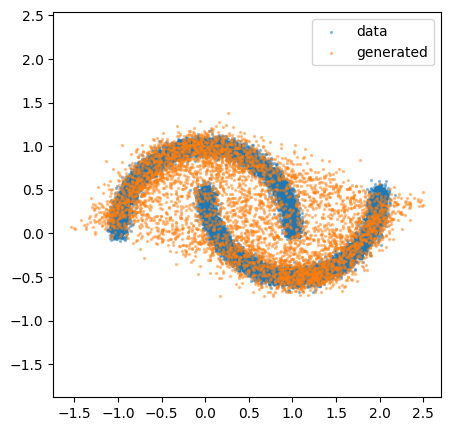

In [12]:
from keras.callbacks import EarlyStopping

model = VelocityField()

es = EarlyStopping(patience=200, restore_best_weights=True)
opt = Adam(learning_rate=1e-3)
model.compile(optimizer=opt, loss='mse')
history = model.fit(train_seq, validation_data=val_seq, epochs=200, callbacks=[es])

samples = sample_flow_keras(model, n_samples=5000, n_steps=1000)

plt.figure(figsize=(5,5))
plt.scatter(train_x[:,0], train_x[:,1], s=2, alpha=0.4, label='data')
plt.scatter(samples[:,0], samples[:,1], s=2, alpha=0.4, label='generated')
plt.legend()
plt.axis('equal')
plt.show()